SUMMARY --
Three regression models were compared using 5-fold cross-validation. Tree-based models outperformed the linear ElasticNet, indicating that the relationship between the features and hallucination risk is nonlinear. Random forest had the lowest MAE, while gradient boosting achieved the best RMSE and R² and showed more stable performance across folds. Based on overall performance, gradient boosting was selected as the final model. On the held-out test set it achieved MAE ≈ 0.221, RMSE ≈ 0.284, and R² ≈ 0.53, indicating that the features explain a little over half of the variation in p_hat. This suggests the spectral and semantic features contain meaningful signal about hallucination risk, though predictions remain somewhat noisy due to the variability of the target. This makes sense given our relatively low sampling data-generation pipeline.

NOTES --
This training uses the full aggregated dataset and mixes questions agnostically. We also dropped features that had high (>=90%) correlation with another feature, and also dropped mahalonbis features (in previous experiments we found the mahalanobis features did not contribute much signal, and they use prior knowledge of response-level labels in a way that the other features do not). We should do future ablation studies to test the impact of holding out specific datasets for testing vs having all datasets equally represented during training. Perhaps we should also do future training with respect to probability ranges as "classes," e.g instead of a binary split we could do low/medium/high risk or so on. Or simply do 20 classes, one for each proportion of the 20 samples possible.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

X_full = pd.read_csv("full_feature_matrix.csv")

X = X_full.drop(columns=["Unnamed: 0", "dataset","q_id","p_hat","y", "lam3", "cluster_gap", "singleton_cluster_frac", "largest_cluster_frac", "HFER","mean_pairwise_cosdist", "lam3_minus_lam2", "second_largest_cluster_frac", "Mbar", "Mvar","Mmax"])

p = X_full["p_hat"]
y = X_full["y"]

X.head()

,var_pairwise_cossim,mean_centroid_cosdist,var_centroid_cosdist,K,H_sem,lam2,SGR,spectral_entropy,ipr_fiedler
0,0.045926,0.217717,0.017053,11,3.001609,7.610835,0.855160,4.220467,0.115052
1,0.073850,0.281187,0.024592,11,2.921928,4.333150,0.723309,4.192606,0.159055
2,0.026550,0.339244,0.012629,18,4.121928,4.783460,0.888493,4.215498,0.488723
3,0.041397,0.097322,0.015608,3,1.076298,7.624615,0.596151,4.228067,0.890134
4,0.037540,0.306600,0.012053,14,3.446439,5.536157,0.822903,4.219021,0.205027


In [2]:
X_train, X_test, p_train, p_test = train_test_split(
    X,
    p,
    test_size=0.2
)

In [18]:
import numpy as np
import pandas as pd

from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=42)

models = {
    "elasticnet_reg": Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000))
    ]),
    "random_forest_reg": RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    ),
    "gradient_boosting_reg": GradientBoostingRegressor(
        random_state=42
    )
}

results = []

for name, model in models.items():
    print(f"\ntraining model: {name}\n")

    fold_maes = []
    fold_rmses = []
    fold_r2s = []

    for fold, (train_idx, val_idx) in enumerate(cv.split(X_train), start=1):
        X_tr = X_train.iloc[train_idx]
        p_tr = p_train.iloc[train_idx]

        X_val = X_train.iloc[val_idx]
        p_val = p_train.iloc[val_idx]

        model.fit(X_tr, p_tr)

        p_pred = model.predict(X_val)
        p_pred = np.clip(p_pred, 0, 1)

        mae = mean_absolute_error(p_val, p_pred)
        rmse = np.sqrt(mean_squared_error(p_val, p_pred))
        r2 = r2_score(p_val, p_pred)

        fold_maes.append(mae)
        fold_rmses.append(rmse)
        fold_r2s.append(r2)

        print(f"fold {fold}: mae={mae:.4f}  rmse={rmse:.4f}  r2={r2:.4f}")

    results.append({
        "model": name,
        "mean_mae": np.mean(fold_maes),
        "std_mae": np.std(fold_maes),
        "mean_rmse": np.mean(fold_rmses),
        "std_rmse": np.std(fold_rmses),
        "mean_r2": np.mean(fold_r2s),
        "std_r2": np.std(fold_r2s)
    })

summary_df = pd.DataFrame(results)

# --------------------------------------------------
# best-overall selection by combined ranks
# --------------------------------------------------

summary_df["rank_mae"] = summary_df["mean_mae"].rank(method="min", ascending=True)
summary_df["rank_rmse"] = summary_df["mean_rmse"].rank(method="min", ascending=True)
summary_df["rank_r2"] = summary_df["mean_r2"].rank(method="min", ascending=False)

# stability score: smaller total std is better
summary_df["stability_score"] = (
    summary_df["std_mae"] +
    summary_df["std_rmse"] +
    summary_df["std_r2"]
)
summary_df["rank_stability"] = summary_df["stability_score"].rank(method="min", ascending=True)

summary_df["overall_rank_score"] = (
    summary_df["rank_mae"] +
    summary_df["rank_rmse"] +
    summary_df["rank_r2"] +
    summary_df["rank_stability"]
)

summary_df = summary_df.sort_values(
    ["overall_rank_score", "rank_rmse", "rank_r2", "rank_mae"],
    ascending=[True, True, True, True]
).reset_index(drop=True)

print("\nmodel comparison summary\n")
print(summary_df)

best_model_name = summary_df.iloc[0]["model"]
print(f"\nbest overall model on training data: {best_model_name}")


training model: elasticnet_reg

fold 1: mae=0.2542  rmse=0.3013  r2=0.4362
fold 2: mae=0.2550  rmse=0.3062  r2=0.4445
fold 3: mae=0.2526  rmse=0.2978  r2=0.4582
fold 4: mae=0.2368  rmse=0.2775  r2=0.5121
fold 5: mae=0.2456  rmse=0.2884  r2=0.4963

training model: random_forest_reg

fold 1: mae=0.2316  rmse=0.3048  r2=0.4231
fold 2: mae=0.2244  rmse=0.3161  r2=0.4079
fold 3: mae=0.2234  rmse=0.2950  r2=0.4684
fold 4: mae=0.2080  rmse=0.2769  r2=0.5143
fold 5: mae=0.2122  rmse=0.2854  r2=0.5068

training model: gradient_boosting_reg

fold 1: mae=0.2326  rmse=0.2981  r2=0.4481
fold 2: mae=0.2233  rmse=0.3044  r2=0.4510
fold 3: mae=0.2298  rmse=0.2970  r2=0.4614
fold 4: mae=0.2112  rmse=0.2736  r2=0.5258
fold 5: mae=0.2142  rmse=0.2849  r2=0.5087

model comparison summary

                   model  mean_mae   std_mae  mean_rmse  std_rmse   mean_r2  \
0  gradient_boosting_reg  0.222224  0.008385   0.291593  0.010997  0.479000   
1         elasticnet_reg  0.248812  0.006874   0.294269  0.01

In [19]:
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

if best_model_name == "elasticnet_reg":
    final_model = Pipeline([
        ("scaler", StandardScaler()),
        ("model", ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000))
    ])

elif best_model_name == "random_forest_reg":
    final_model = RandomForestRegressor(
        n_estimators=300,
        random_state=42,
        n_jobs=-1
    )

elif best_model_name == "gradient_boosting_reg":
    final_model = GradientBoostingRegressor(
        random_state=42
    )

else:
    raise ValueError(f"unknown model name: {best_model_name}")

final_model.fit(X_train, p_train)

p_test_pred = final_model.predict(X_test)
p_test_pred = np.clip(p_test_pred, 0, 1)

residuals = np.asarray(p_test) - p_test_pred
abs_errors = np.abs(residuals)

test_metrics = {
    "mae": mean_absolute_error(p_test, p_test_pred),
    "rmse": np.sqrt(mean_squared_error(p_test, p_test_pred)),
    "r2": r2_score(p_test, p_test_pred),
    "mean_residual": np.mean(residuals),
    "median_abs_error": np.median(abs_errors)
}

print("\nfinal model:", best_model_name)
print("\nfinal test-set regression metrics")
print("=" * 70)
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}")


final model: gradient_boosting_reg

final test-set regression metrics
mae: 0.2207
rmse: 0.2841
r2: 0.5287
mean_residual: -0.0112
median_abs_error: 0.1693


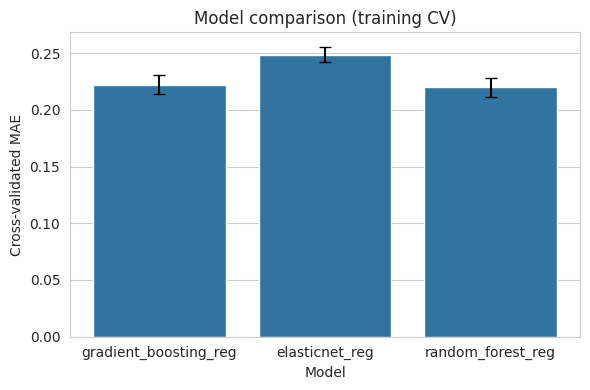

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

plt.figure(figsize=(6, 4))
sns.barplot(
    data=summary_df,
    x="model",
    y="mean_mae"
)

plt.errorbar(
    x=range(len(summary_df)),
    y=summary_df["mean_mae"],
    yerr=summary_df["std_mae"],
    fmt="none",
    c="black",
    capsize=4
)

plt.ylabel("Cross-validated MAE")
plt.xlabel("Model")
plt.title("Model comparison (training CV)")
plt.tight_layout()
plt.show()

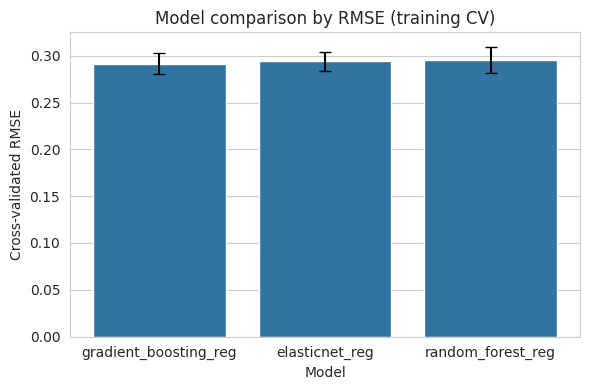

In [21]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=summary_df,
    x="model",
    y="mean_rmse"
)

plt.errorbar(
    x=range(len(summary_df)),
    y=summary_df["mean_rmse"],
    yerr=summary_df["std_rmse"],
    fmt="none",
    c="black",
    capsize=4
)

plt.ylabel("Cross-validated RMSE")
plt.xlabel("Model")
plt.title("Model comparison by RMSE (training CV)")
plt.tight_layout()
plt.show()

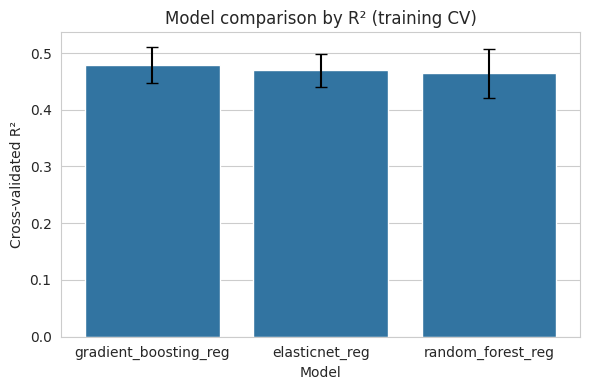

In [22]:
plt.figure(figsize=(6, 4))
sns.barplot(
    data=summary_df,
    x="model",
    y="mean_r2"
)

plt.errorbar(
    x=range(len(summary_df)),
    y=summary_df["mean_r2"],
    yerr=summary_df["std_r2"],
    fmt="none",
    c="black",
    capsize=4
)

plt.ylabel("Cross-validated R²")
plt.xlabel("Model")
plt.title("Model comparison by R² (training CV)")
plt.tight_layout()
plt.show()

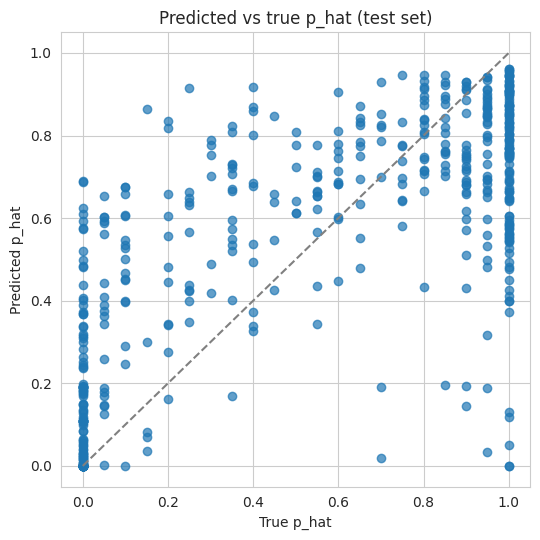

In [23]:
pred_df = results_bundle["test_pred_df"]

plt.figure(figsize=(5.5, 5.5))
plt.scatter(pred_df["p_true"], pred_df["p_pred"], alpha=0.7)
plt.plot([0, 1], [0, 1], "--", color="gray")

plt.xlabel("True p_hat")
plt.ylabel("Predicted p_hat")
plt.title("Predicted vs true p_hat (test set)")
plt.tight_layout()
plt.show()

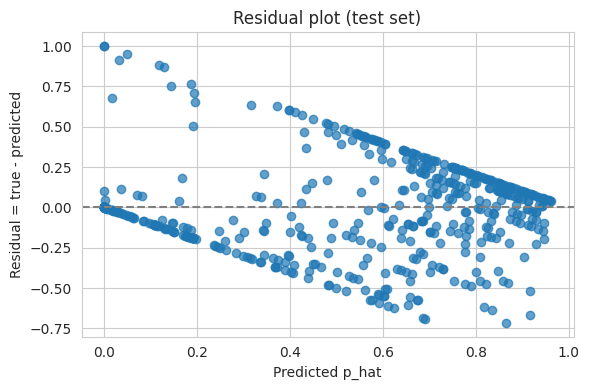

In [24]:
plt.figure(figsize=(6, 4))
plt.scatter(pred_df["p_pred"], pred_df["residual"], alpha=0.7)
plt.axhline(0, linestyle="--", color="gray")

plt.xlabel("Predicted p_hat")
plt.ylabel("Residual = true - predicted")
plt.title("Residual plot (test set)")
plt.tight_layout()
plt.show()

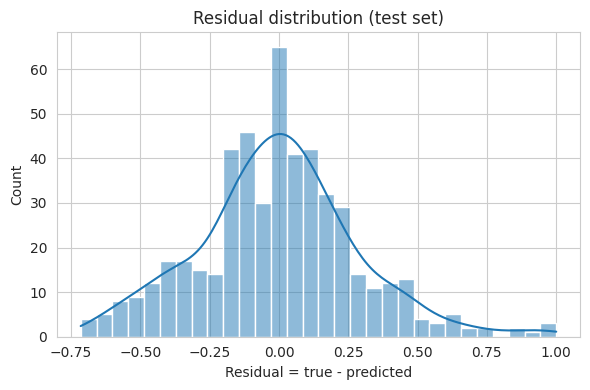

In [25]:
plt.figure(figsize=(6, 4))
sns.histplot(pred_df["residual"], bins=30, kde=True)

plt.xlabel("Residual = true - predicted")
plt.title("Residual distribution (test set)")
plt.tight_layout()
plt.show()

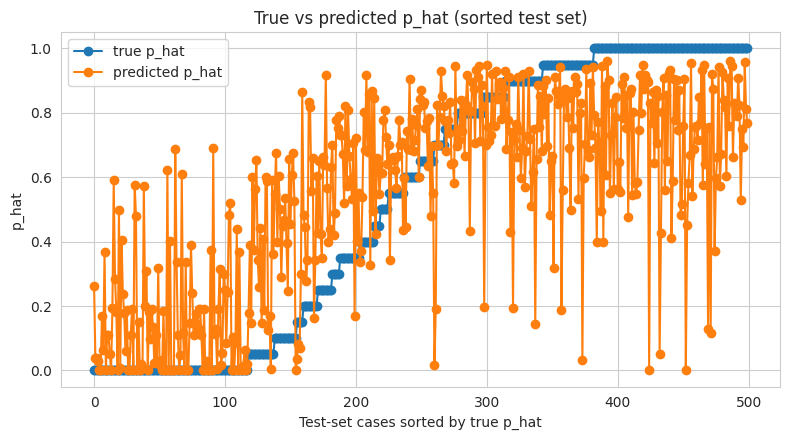

In [26]:
sorted_df = results_bundle["sorted_pred_df"]

plt.figure(figsize=(8, 4.5))
plt.plot(sorted_df["rank"], sorted_df["p_true"], label="true p_hat", marker="o")
plt.plot(sorted_df["rank"], sorted_df["p_pred"], label="predicted p_hat", marker="o")

plt.xlabel("Test-set cases sorted by true p_hat")
plt.ylabel("p_hat")
plt.title("True vs predicted p_hat (sorted test set)")
plt.legend()
plt.tight_layout()
plt.show()

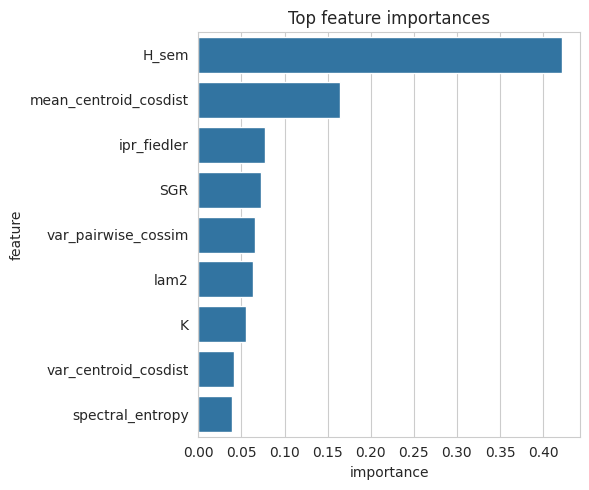

In [27]:
coef_df = results_bundle["coef_df"]
feature_importance_df = results_bundle["feature_importance_df"]

if coef_df is not None:
    top = coef_df.head(15)

    plt.figure(figsize=(6, 5))
    sns.barplot(
        data=top,
        x="coefficient",
        y="feature"
    )

    plt.axvline(0, color="black")
    plt.title("Top feature coefficients (elastic-net regression)")
    plt.tight_layout()
    plt.show()

elif feature_importance_df is not None:
    top = feature_importance_df.head(15)

    plt.figure(figsize=(6, 5))
    sns.barplot(
        data=top,
        x="importance",
        y="feature"
    )

    plt.title("Top feature importances")
    plt.tight_layout()
    plt.show()

500 500


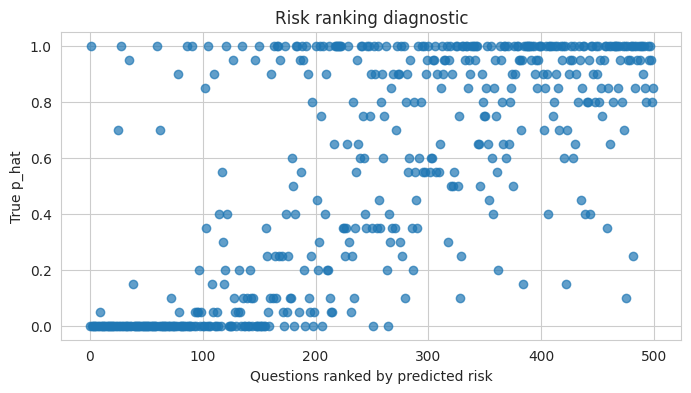

In [28]:
import numpy as np
import matplotlib.pyplot as plt

p_pred = final_model.predict(X_test)
p_pred = np.clip(p_pred, 0, 1)

true_p = np.asarray(p_test).ravel()
pred_p = np.asarray(p_pred).ravel()

print(len(true_p), len(pred_p))

df_rank = pd.DataFrame({
    "true_p": true_p,
    "pred_p": pred_p
})

df_rank = pd.DataFrame({
    "true_p": p_test,
    "pred_p": p_pred
})

# sort by predicted risk
df_rank = df_rank.sort_values("pred_p").reset_index(drop=True)

df_rank["rank"] = np.arange(len(df_rank))

plt.figure(figsize=(8,4))

plt.plot(
    df_rank["rank"],
    df_rank["true_p"],
    marker="o",
    linestyle="none",
    alpha=0.7
)

plt.xlabel("Questions ranked by predicted risk")
plt.ylabel("True p_hat")
plt.title("Risk ranking diagnostic")

plt.show()

500 500


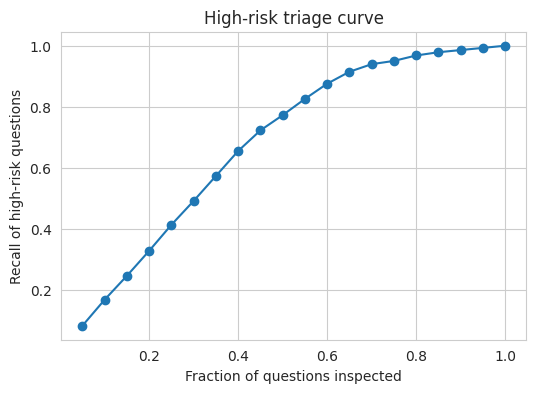

In [29]:
import numpy as np
import matplotlib.pyplot as plt

p_pred = final_model.predict(X_test)
p_pred = np.clip(p_pred, 0, 1)

true_p = np.asarray(p_test).ravel()
pred_p = np.asarray(p_pred).ravel()

print(len(true_p), len(pred_p))

df_rank = pd.DataFrame({
    "true_p": true_p,
    "pred_p": pred_p
})

df_eval = pd.DataFrame({
    "true_p": p_test,
    "pred_p": p_pred
})

# define high-risk questions
threshold = 0.5
df_eval["high_risk"] = df_eval["true_p"] >= threshold

# sort by predicted risk (descending)
df_eval = df_eval.sort_values("pred_p", ascending=False).reset_index(drop=True)

N = len(df_eval)

fractions = np.linspace(0.05, 1.0, 20)
recalls = []

total_high_risk = df_eval["high_risk"].sum()

for frac in fractions:

    k = int(frac * N)

    subset = df_eval.iloc[:k]

    captured = subset["high_risk"].sum()

    recall = captured / total_high_risk if total_high_risk > 0 else 0

    recalls.append(recall)

plt.figure(figsize=(6,4))

plt.plot(fractions, recalls, marker="o")

plt.xlabel("Fraction of questions inspected")
plt.ylabel("Recall of high-risk questions")

plt.title("High-risk triage curve")

plt.show()

true_p shape: (500,)
pred_p shape: (500,)


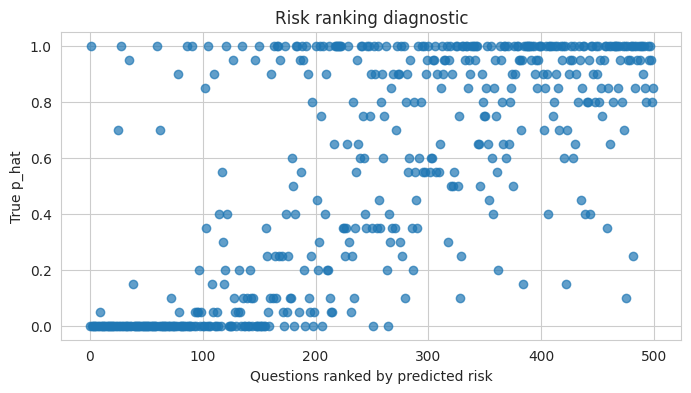

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# regenerate predictions from the current test set
p_pred = final_model.predict(X_test)
p_pred = np.clip(p_pred, 0, 1)

true_p = np.asarray(p_test).ravel()
pred_p = np.asarray(p_pred).ravel()

print("true_p shape:", true_p.shape)
print("pred_p shape:", pred_p.shape)

assert len(true_p) == len(pred_p), "p_test and p_pred do not have the same length"

df_rank = pd.DataFrame({
    "true_p": true_p,
    "pred_p": pred_p
})

df_rank = df_rank.sort_values("pred_p").reset_index(drop=True)
df_rank["rank"] = np.arange(len(df_rank))

plt.figure(figsize=(8, 4))
plt.plot(
    df_rank["rank"],
    df_rank["true_p"],
    marker="o",
    linestyle="none",
    alpha=0.7
)
plt.xlabel("Questions ranked by predicted risk")
plt.ylabel("True p_hat")
plt.title("Risk ranking diagnostic")
plt.show()

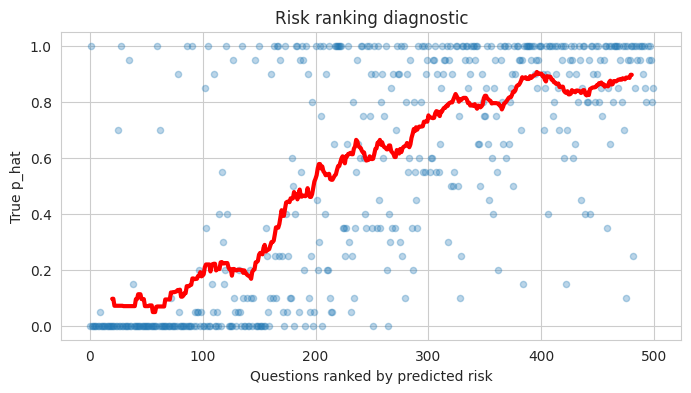

In [31]:
df_rank["rolling_mean"] = (
    df_rank["true_p"]
    .rolling(window=40, center=True)
    .mean()
)
plt.figure(figsize=(8,4))

plt.scatter(
    df_rank["rank"],
    df_rank["true_p"],
    alpha=0.3,
    s=20
)

plt.plot(
    df_rank["rank"],
    df_rank["rolling_mean"],
    color="red",
    linewidth=3
)

plt.xlabel("Questions ranked by predicted risk")
plt.ylabel("True p_hat")
plt.title("Risk ranking diagnostic")

plt.show()

In [32]:
from scipy.stats import spearmanr

rho, p = spearmanr(p_test, p_pred)

print("Spearman correlation:", rho)

Spearman correlation: 0.6815940173092172
